正在加载数据...
正在进行包络分析...


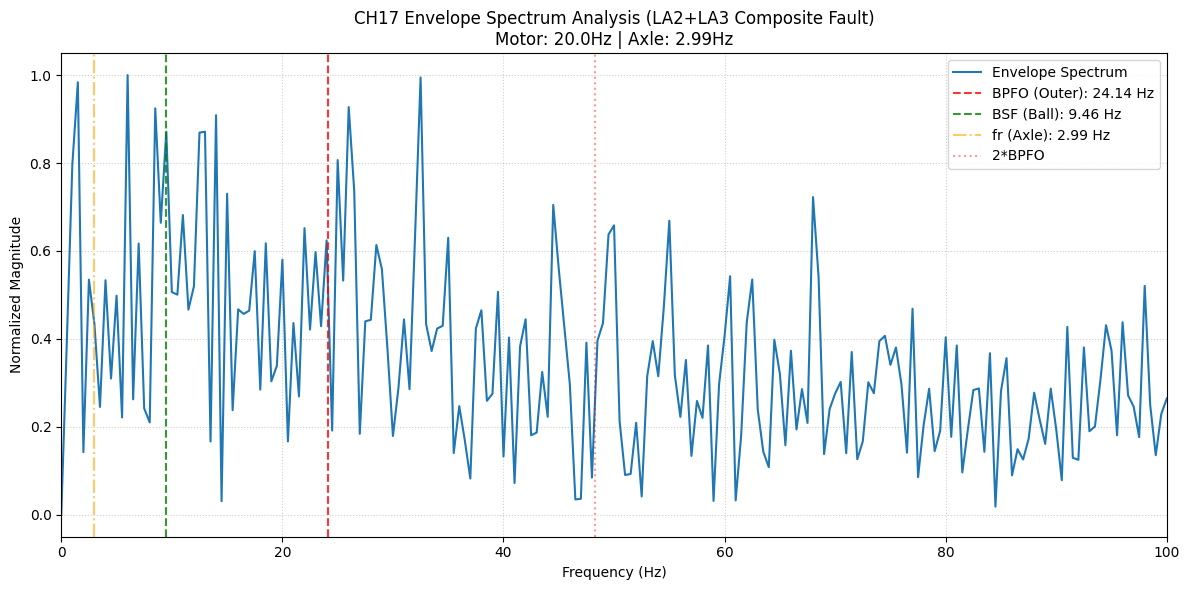

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# ==========================================
# 1. 基础参数设置 (BJTU 数据集实测参数)
# ==========================================
file_path = 'BJTU/0负载/data_leftaxlebox_M0_G0_LA1_RA0_20Hz_0kN.csv'
fs = 64000              # 原始采样率 64kHz
f_motor = 20.0          # 电机输入频率 20Hz
gear_ratio = 107 / 16   # 实验台减速比 (i)
fr = f_motor / gear_ratio # 实际车轴转频 (~2.99 Hz)

# HRB 352213 轴承故障特征系数
coeffs = {
    'BPFO': 8.071,  # 外圈故障系数
    'BSF': 3.164,   # 滚动体故障系数
}

# 计算理论故障频率
f_bpfo = fr * coeffs['BPFO']  # 约 24.14 Hz
f_bsf = fr * coeffs['BSF']    # 约 9.46 Hz

# ==========================================
# 2. 数据加载与预处理
# ==========================================
print("正在加载数据...")
df = pd.read_csv(file_path)
sig = df['CH17'].values

# 为了提高计算效率和频率分辨率，取前 2 秒数据 (128,000 个点)
seg_len = 128000 
sig_seg = sig[:seg_len]

# ==========================================
# 3. 包络分析 (Hilbert Transform)
# ==========================================
print("正在进行包络分析...")
# 执行希尔伯特变换
analytic_signal = hilbert(sig_seg)
# 提取瞬时幅值（即包络线）
amplitude_envelope = np.abs(analytic_signal)
# 去除直流分量（让谱图基准线对齐 0）
envelope_detrended = amplitude_envelope - np.mean(amplitude_envelope)

# 计算包络线的 FFT
n = len(envelope_detrended)
env_fft = np.fft.fft(envelope_detrended)
freqs = np.fft.fftfreq(n, 1/fs)

# 筛选正频率范围 (关注 0-100Hz 故障特征区)
mask = (freqs >= 0) & (freqs <= 100)
f_plot = freqs[mask]
s_plot = np.abs(env_fft[mask])

# 幅值归一化（可选，方便观察相对强度）
s_plot = s_plot / np.max(s_plot)

# ==========================================
# 4. 绘图与标注
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(f_plot, s_plot, color='#1f77b4', linewidth=1.5, label='Envelope Spectrum')

# 标注理论故障频率
plt.axvline(f_bpfo, color='red', linestyle='--', alpha=0.8, 
            label=f'BPFO (Outer): {f_bpfo:.2f} Hz')
plt.axvline(f_bsf, color='green', linestyle='--', alpha=0.8, 
            label=f'BSF (Ball): {f_bsf:.2f} Hz')

# 标注转频及倍频
plt.axvline(fr, color='orange', linestyle='-.', alpha=0.6, 
            label=f'fr (Axle): {fr:.2f} Hz')
plt.axvline(2 * f_bpfo, color='red', linestyle=':', alpha=0.4, label='2*BPFO')

# 图形修饰
plt.title(f"CH17 Envelope Spectrum Analysis (LA2+LA3 Composite Fault)\nMotor: {f_motor}Hz | Axle: {fr:.2f}Hz", fontsize=12)
plt.xlabel("Frequency (Hz)", fontsize=10)
plt.ylabel("Normalized Magnitude", fontsize=10)
plt.xlim(0, 100)  # 重点观察低频故障区
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show() # 如果在脚本中运行请保留，如果在 Notebook 运行会自动显示